**1. IMPORT LIBRARY**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

print("Library berhasil diimport!")

Library berhasil diimport!


**2. LOAD DATASET**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/janiobachmann/bank-marketing-dataset/bank.csv')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


# BUSINESS UNDERSTANDING

## Latar Belakang

Industri perbankan menghadapi tantangan dalam meningkatkan efektivitas kampanye pemasaran produk deposito. Tidak semua nasabah memiliki kemungkinan yang sama untuk menerima penawaran deposito, sehingga diperlukan strategi pemasaran yang lebih terarah.

Pemanfaatan data mining dapat membantu bank dalam mengidentifikasi pola perilaku nasabah, melakukan segmentasi pelanggan, serta memprediksi kemungkinan nasabah untuk berlangganan deposito.

Dalam penelitian ini digunakan pendekatan supervised learning dan unsupervised learning menggunakan metode K-Means Clustering, Logistic Regression, dan Naïve Bayes untuk menganalisis perilaku nasabah berdasarkan dataset Bank Marketing.

## Rumusan Masalah

1. Bagaimana segmentasi nasabah berdasarkan karakteristik data menggunakan metode K-Means?
2. Bagaimana performa Logistic Regression dalam memprediksi keputusan deposito?
3. Bagaimana performa Naïve Bayes dalam memprediksi keputusan deposito?
4. Metode manakah yang memberikan hasil terbaik?

## Tujuan Penelitian

1. Melakukan segmentasi nasabah menggunakan K-Means.
2. Memprediksi keputusan deposito menggunakan Logistic Regression.
3. Memprediksi keputusan deposito menggunakan Naïve Bayes.
4. Membandingkan performa kedua model klasifikasi.

## Metodologi

Penelitian menggunakan pendekatan CRISP-DM:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

**3. DATA UNDERSTANDING**

In [3]:
print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

Jumlah Baris dan Kolom:
(11162, 17)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


**MISSING VALUE**

In [4]:
missing_values = df.isnull().sum()

print("Jumlah Missing Value:")
print(missing_values)

Jumlah Missing Value:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


**Statistik Deskriptif**

In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
print("Daftar Kolom Dataset:")
print(df.columns.tolist())

Daftar Kolom Dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


**Distribusi Target**

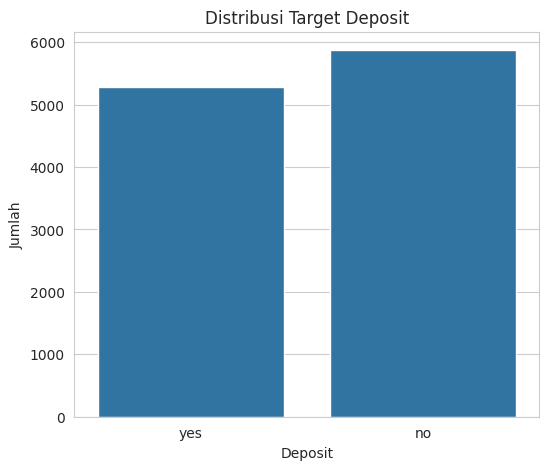

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='deposit')

plt.title("Distribusi Target Deposit")
plt.xlabel("Deposit")
plt.ylabel("Jumlah")
plt.show()

In [8]:
deposit_percentage = (
    df['deposit']
    .value_counts(normalize=True)
    * 100
)

print(deposit_percentage)

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


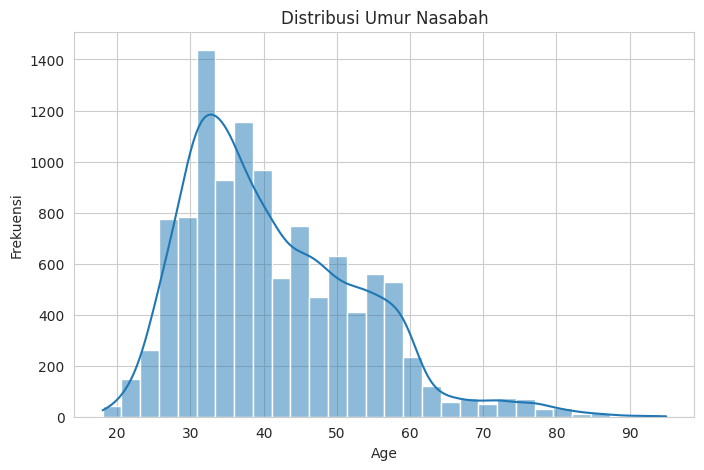

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title("Distribusi Umur Nasabah")
plt.xlabel("Age")
plt.ylabel("Frekuensi")

plt.show()

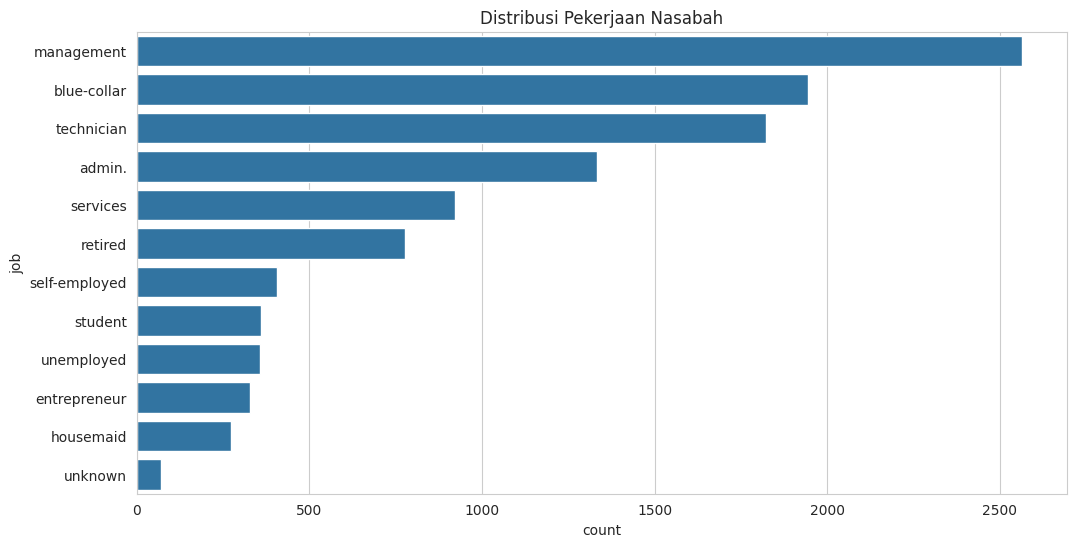

In [10]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['job'],
    order=df['job'].value_counts().index
)

plt.title("Distribusi Pekerjaan Nasabah")

plt.show()

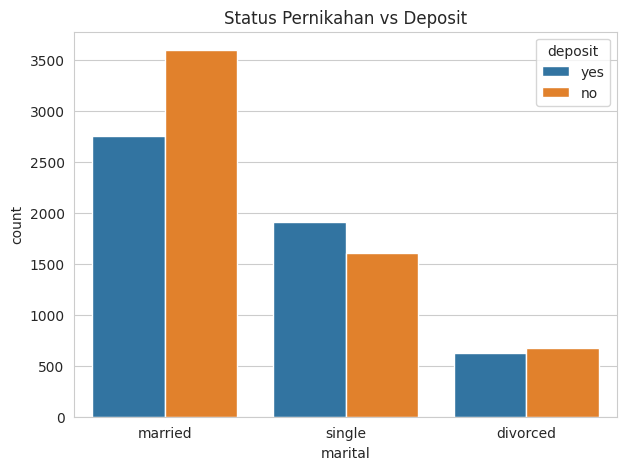

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='marital',
    hue='deposit'
)

plt.title("Status Pernikahan vs Deposit")

plt.show()

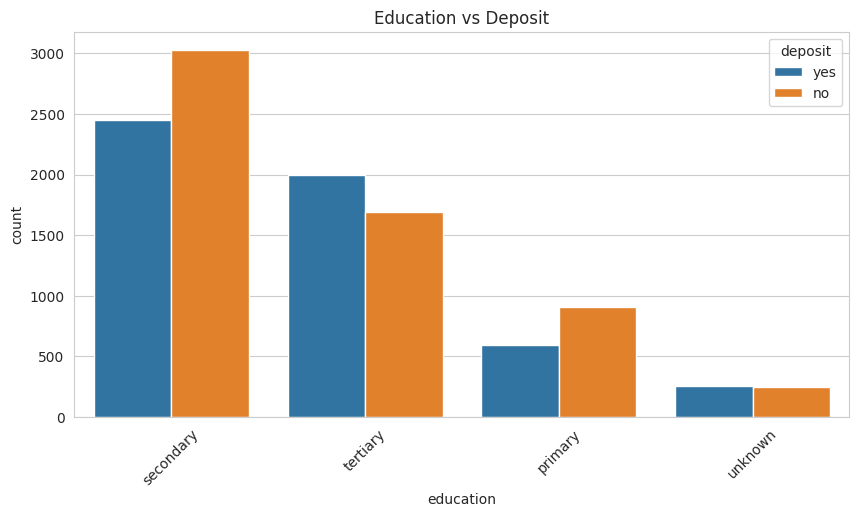

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='education',
    hue='deposit'
)

plt.xticks(rotation=45)

plt.title("Education vs Deposit")

plt.show()

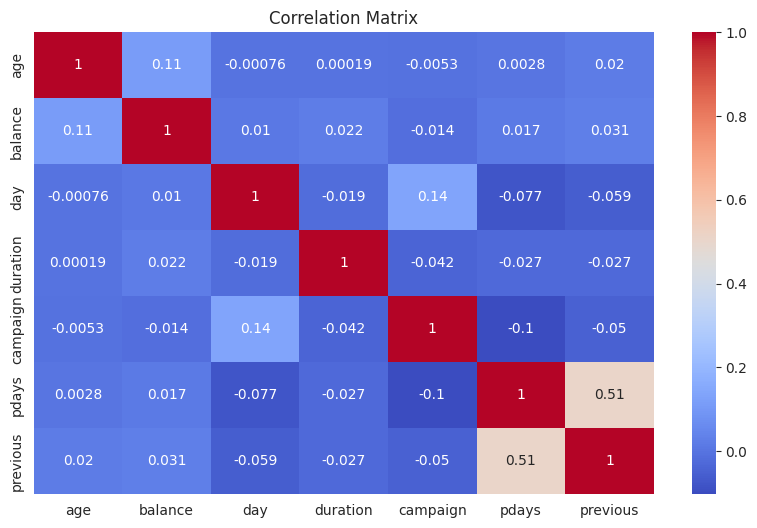

In [13]:
numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# Insight Awal Dataset

Berdasarkan hasil eksplorasi data diperoleh beberapa temuan awal:

1. Sebagian besar nasabah tidak melakukan deposito.
2. Rentang usia nasabah cukup beragam, dengan dominasi pada usia produktif.
3. Beberapa jenis pekerjaan memiliki kecenderungan lebih tinggi dalam melakukan deposito.
4. Tingkat pendidikan berpengaruh terhadap keputusan deposito.
5. Korelasi antar variabel numerik relatif rendah sehingga diperlukan pendekatan machine learning untuk menemukan pola tersembunyi.

**4. DATA PREPARATION**

In [14]:
duplicates = df.duplicated().sum()

print("Jumlah Data Duplikat:", duplicates)

Jumlah Data Duplikat: 0


**Encoding data**

In [15]:
y = df['deposit']                  # target
X = df.drop('deposit', axis=1)    # fitur

X = pd.get_dummies(X, drop_first=True)

y = y.map({'yes': 1, 'no': 0})

cols = X.columns

print("Shape X:", X.shape)
print("Shape y:", y.shape)

X.head()

Shape X: (11162, 42)
Shape y: (11162,)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [16]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  11162 non-null  int64
 1   balance              11162 non-null  int64
 2   day                  11162 non-null  int64
 3   duration             11162 non-null  int64
 4   campaign             11162 non-null  int64
 5   pdays                11162 non-null  int64
 6   previous             11162 non-null  int64
 7   job_blue-collar      11162 non-null  bool 
 8   job_entrepreneur     11162 non-null  bool 
 9   job_housemaid        11162 non-null  bool 
 10  job_management       11162 non-null  bool 
 11  job_retired          11162 non-null  bool 
 12  job_self-employed    11162 non-null  bool 
 13  job_services         11162 non-null  bool 
 14  job_student          11162 non-null  bool 
 15  job_technician       11162 non-null  bool 
 16  job_unemployed       1

**Feature Selection**

In [17]:
df_corr = X.copy()
df_corr['deposit'] = y
corr_target = df_corr.corr()['deposit'].abs().sort_values(ascending=False)

selected_features = corr_target.drop('deposit', errors='ignore')

selected_features = selected_features[selected_features > 0.1]

print(selected_features)

duration            0.451919
poutcome_success    0.286642
contact_unknown     0.256136
poutcome_unknown    0.230470
housing_yes         0.203888
month_may           0.170507
pdays               0.151593
previous            0.139867
month_mar           0.135438
month_oct           0.133783
campaign            0.128081
month_sep           0.126901
loan_yes            0.110580
job_retired         0.103827
job_blue-collar     0.100840
Name: deposit, dtype: float64


In [18]:
#duration merupakan data leakage
#selected_features = selected_features.drop('duration', errors='ignore')

In [19]:
X_selected = X[selected_features.index]

**Train test split**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X Train:", X_train.shape)
print("X Test :", X_test.shape)

X Train: (8929, 15)
X Test : (2233, 15)


In [21]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

#fit di train
X_train_scaled = scaler.fit_transform(X_train)

#transform test
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai!")

Scaling selesai!


In [22]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

**K-MEANS CLUSTERING**

Training cluster ke-1
Training cluster ke-2
Training cluster ke-3
Training cluster ke-4
Training cluster ke-5
Training cluster ke-6
Training cluster ke-7
Training cluster ke-8
Training cluster ke-9
Training cluster ke-10

Jumlah data WCSS:
10

Isi WCSS:
[133935.0, 111535.79982940154, 100161.53856511865, 91800.85512552236, 85717.19137688138, 78417.78878494525, 73611.76536643795, 66054.33371859076, 59603.60090527591, 56837.076556861604]


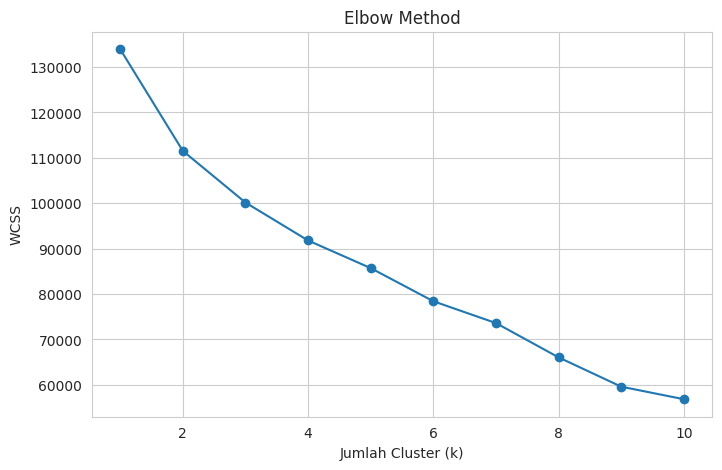

In [23]:
wcss = []

for i in range(1, 11):

    print(f"Training cluster ke-{i}")

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_train_scaled)

    wcss.append(model.inertia_)

print("\nJumlah data WCSS:")
print(len(wcss))

print("\nIsi WCSS:")
print(wcss)

# Plot Elbow Method

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(wcss)+1),
    wcss,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')

plt.show()

**Training K-Means**

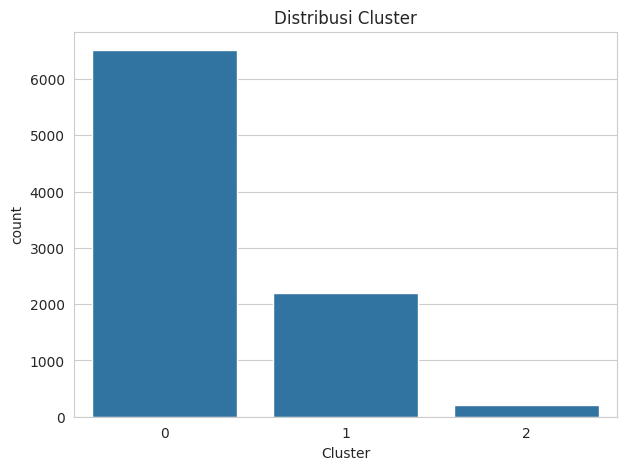

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

df_cluster = X_selected.loc[X_train.index].copy()
df_cluster['Cluster'] = clusters

plt.figure(figsize=(7,5))
sns.countplot(x=df_cluster['Cluster'])
plt.title("Distribusi Cluster")
plt.show()

In [25]:
print("X_train_scaled:", X_train_scaled.shape)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

print("clusters:", len(clusters))

silhouette = silhouette_score(X_train_scaled, clusters)
print("Silhouette Score:", silhouette)

X_train_scaled: (8929, 15)
clusters: 8929
Silhouette Score: 0.2806712375435321


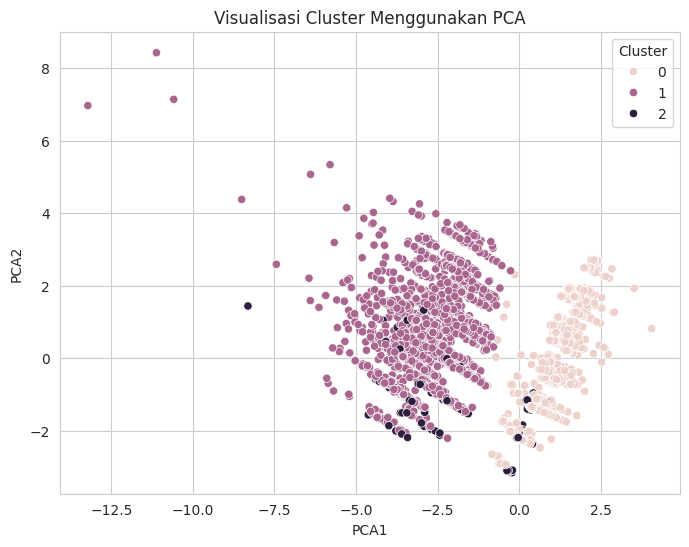

In [26]:
from sklearn.decomposition import PCA

# PCA 2 dimensi
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

cluster_df = pd.DataFrame()

cluster_df['PCA1'] = X_pca[:,0]
cluster_df['PCA2'] = X_pca[:,1]
cluster_df['Cluster'] = clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cluster_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster'
)

plt.title("Visualisasi Cluster Menggunakan PCA")

plt.show()

**Rata-rata tiap cluster**

In [27]:
# Cell cluster_summary
df_cluster_summary = X_selected.loc[X_train.index].copy()
df_cluster_summary['Cluster'] = clusters
df_cluster_summary['deposit'] = y.loc[X_train.index]

cluster_summary = df_cluster_summary.groupby('Cluster').mean()
pd.set_option('display.max_columns', None)
cluster_summary

,duration,poutcome_success,contact_unknown,poutcome_unknown,housing_yes,month_may,pdays,previous,month_mar,month_oct,campaign,month_sep,loan_yes,job_retired,job_blue-collar,deposit
Cluster,,,,,,,,,,,,,,,,
0,381.218112,0.000000,0.285495,0.999079,0.488104,0.271527,-0.986800,0.000921,0.0,0.024252,2.729547,0.014428,0.142748,0.062164,0.191097,0.396777
1,343.328636,0.376364,0.005909,0.000455,0.455000,0.232727,206.220909,3.240455,0.0,0.073636,1.897273,0.067273,0.097727,0.079091,0.130909,0.661364
2,302.598131,0.163551,0.014019,0.621495,0.224299,0.000000,71.102804,1.280374,1.0,0.000000,1.841121,0.000000,0.051402,0.154206,0.042056,0.892523


# Insight Clustering

Berdasarkan hasil K-Means Clustering (Silhouette Score = 0.28, menunjukkan 
struktur cluster yang cukup lemah/overlap namun masih informatif) diperoleh 
3 kelompok nasabah:

1. Cluster 0 (proporsi deposit ~39.7%):
   Mayoritas nasabah belum pernah dikontak pada campaign sebelumnya 
   (poutcome_unknown ~99.9%).

   Kelompok ini merepresentasikan nasabah baru 
   bagi tim marketing, dengan tingkat konversi deposit menengah.

3. Cluster 1 (proporsi deposit ~66.1%, tertinggi kedua):
   Kelompok dengan riwayat campaign sebelumnya yang relatif berhasil 
   (poutcome_success ~37.6%) dan frekuensi kontak sebelumnya tinggi 
   (previous ~3.24).

   Nasabah ini menunjukkan pola responsif terhadap 
   pendekatan berulang.

5. Cluster 2 (proporsi deposit ~89.3%, tertinggi):
   Seluruh nasabah dalam cluster ini dikontak pada bulan Maret, dengan 
   profil pekerjaan blue-collar dan kepemilikan pinjaman yang relatif 
   rendah.

   Cluster ini menunjukkan tingkat konversi deposit paling tinggi, 
   mengindikasikan kombinasi waktu kontak dan profil nasabah tertentu 
   sangat berpengaruh terhadap keputusan deposito.

Silhouette Score sebesar 0.28 mengindikasikan batas antar cluster tidak 
terlalu tegas, namun perbedaan proporsi deposit antar cluster (39.7% vs 
66.1% vs 89.3%) tetap menunjukkan segmentasi ini bermanfaat secara bisnis 
untuk menentukan target campaign.

**3. LOGISTIC REGRESSION**

In [28]:
logreg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Training model
logreg.fit(X_train_scaled, y_train)

# Prediksi
y_pred_logreg = logreg.predict(X_test_scaled)

print("Training Logistic Regression selesai!")

Training Logistic Regression selesai!


**EVALUATION LOGISTIC REGRESSION**

In [29]:
accuracy_log = accuracy_score(
    y_test,
    y_pred_logreg
)

precision_log = precision_score(
    y_test,
    y_pred_logreg
)

recall_log = recall_score(
    y_test,
    y_pred_logreg
)

f1_log = f1_score(
    y_test,
    y_pred_logreg
)

print("=== Logistic Regression ===")
print("Accuracy :", round(accuracy_log,4))
print("Precision:", round(precision_log,4))
print("Recall   :", round(recall_log,4))
print("F1 Score :", round(f1_log,4))

=== Logistic Regression ===
Accuracy : 0.8159
Precision: 0.8291
Recall   : 0.7703
F1 Score : 0.7986


In [30]:
print(classification_report(
    y_test,
    y_pred_logreg
))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1175
           1       0.83      0.77      0.80      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.81      0.81      2233
weighted avg       0.82      0.82      0.82      2233



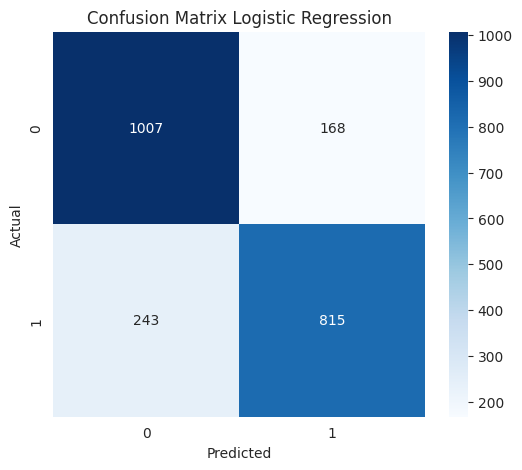

In [31]:
cm_log = confusion_matrix(
    y_test,
    y_pred_logreg
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

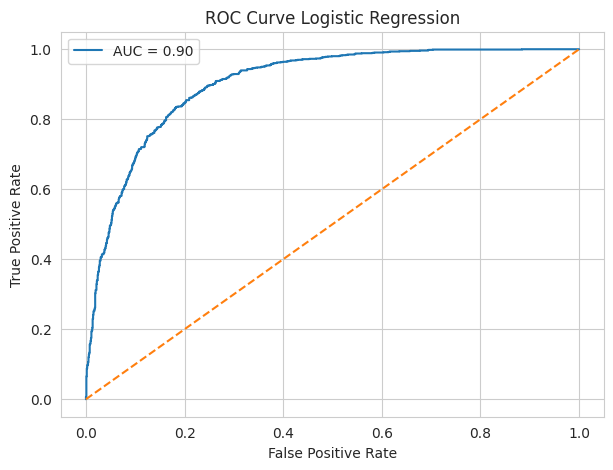

In [32]:
y_prob_log = logreg.predict_proba(X_test_scaled)[:,1]

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_log
)

roc_auc_log = auc(
    fpr_log,
    tpr_log
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'AUC = {roc_auc_log:.2f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Logistic Regression')

plt.legend()

plt.show()

**4. NAIVE BAYES**

In [33]:
nb = GaussianNB()

# Training
nb.fit(X_train_scaled, y_train)

# Prediksi
y_pred_nb = nb.predict(X_test_scaled)

print("Training Naive Bayes selesai!")

Training Naive Bayes selesai!


**EVALUASI NAIVE BAYES**

In [34]:
accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

precision_nb = precision_score(
    y_test,
    y_pred_nb
)

recall_nb = recall_score(
    y_test,
    y_pred_nb
)

f1_nb = f1_score(
    y_test,
    y_pred_nb
)

print("=== Naive Bayes ===")
print("Accuracy :", round(accuracy_nb,4))
print("Precision:", round(precision_nb,4))
print("Recall   :", round(recall_nb,4))
print("F1 Score :", round(f1_nb,4))

=== Naive Bayes ===
Accuracy : 0.7362
Precision: 0.8548
Recall   : 0.534
F1 Score : 0.6574


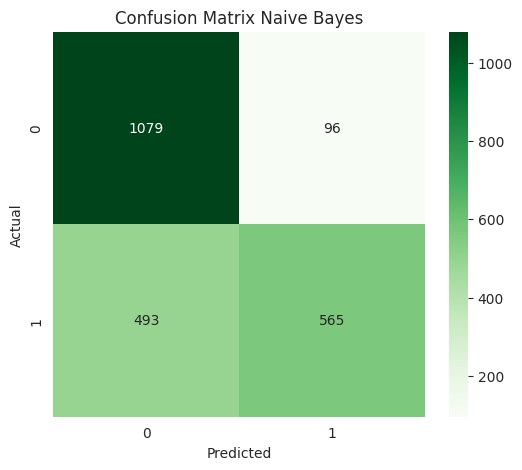

In [35]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
print(classification_report(
    y_test,
    y_pred_nb
))

              precision    recall  f1-score   support

           0       0.69      0.92      0.79      1175
           1       0.85      0.53      0.66      1058

    accuracy                           0.74      2233
   macro avg       0.77      0.73      0.72      2233
weighted avg       0.77      0.74      0.72      2233



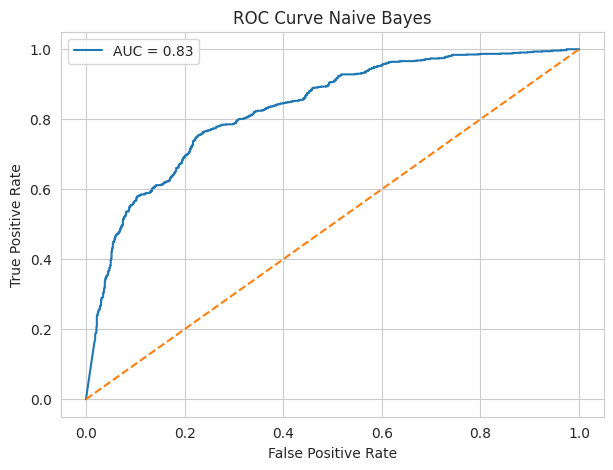

In [37]:
y_prob_nb = nb.predict_proba(X_test_scaled)[:,1]

fpr_nb, tpr_nb, _ = roc_curve(
    y_test,
    y_prob_nb
)

roc_auc_nb = auc(
    fpr_nb,
    tpr_nb
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f'AUC = {roc_auc_nb:.2f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Naive Bayes')

plt.legend()

plt.show()

**perbandingan model**

In [38]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_log,
        accuracy_nb
    ],
    'Precision': [
        precision_log,
        precision_nb
    ],
    'Recall': [
        recall_log,
        recall_nb
    ],
    'F1 Score': [
        f1_log,
        f1_nb
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.815943,0.829095,0.770321,0.798628
1,Naive Bayes,0.736229,0.854766,0.534026,0.657359


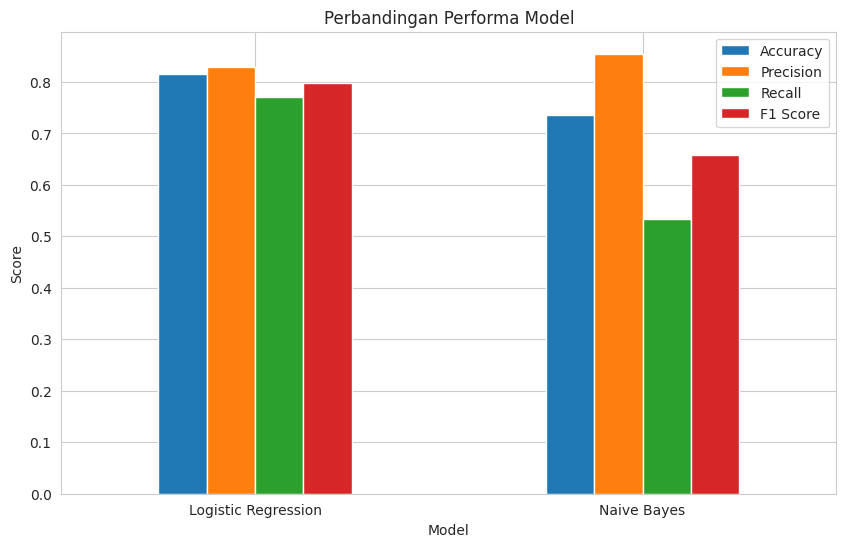

In [39]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

**Tuning model logistic regression**

In [40]:
for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    print(f"C={c}, Accuracy={acc}")

C=0.01, Accuracy=0.8137035378414689
C=0.1, Accuracy=0.8163905060456784
C=1, Accuracy=0.8159426780116436
C=10, Accuracy=0.8159426780116436


**Tuning model naive bayes**

In [41]:
import numpy as np

for v in [1e-9, 1e-6, 1e-3]:
    model = GaussianNB(var_smoothing=v)
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    print(f"var_smoothing={v}, Accuracy={acc}")

var_smoothing=1e-09, Accuracy=0.7362292879534259
var_smoothing=1e-06, Accuracy=0.7362292879534259
var_smoothing=0.001, Accuracy=0.7362292879534259


# Interpretasi Hasil Model

Berdasarkan hasil evaluasi model, Logistic Regression dan Naïve Bayes menunjukkan performa yang baik dalam memprediksi keputusan deposito nasabah.

Evaluasi dilakukan menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.

Model dengan nilai accuracy dan F1-score tertinggi dianggap memiliki performa terbaik dalam klasifikasi keputusan deposito.

Selain itu, ROC Curve menunjukkan kemampuan model dalam membedakan kelas positif dan negatif. Semakin tinggi nilai AUC mendekati 1 maka performa model semakin baik.

**5. VISUALIZATION**

In [42]:
fig = px.pie(
    df,
    names='deposit',
    title='Distribusi Keputusan Deposito Nasabah',
    hole=0.4
)

fig.show()

In [43]:
fig = px.histogram(
    df,
    x='age',
    nbins=30,
    title='Distribusi Umur Nasabah'
)

fig.show()

In [44]:
job_count = df['job'].value_counts()

fig = px.bar(
    x=job_count.index,
    y=job_count.values,
    title='Distribusi Pekerjaan Nasabah',
    labels={
        'x':'Job',
        'y':'Jumlah'
    }
)

fig.show()

In [45]:
fig = px.histogram(
    df,
    x='marital',
    color='deposit',
    barmode='group',
    title='Status Pernikahan terhadap Deposit'
)

fig.show()

In [46]:
fig = px.histogram(
    df,
    x='education',
    color='deposit',
    barmode='group',
    title='Tingkat Pendidikan terhadap Deposit'
)

fig.show()

In [47]:
fig = px.scatter(
    cluster_df,
    x='PCA1',
    y='PCA2',
    color='Cluster',
    title='Visualisasi Cluster Nasabah'
)

fig.show()

# Business Insight

Berdasarkan hasil analisis data mining diperoleh beberapa insight penting:

### 1. Mayoritas Nasabah Tidak Melakukan Deposito
Sebagian besar nasabah pada dataset tidak melakukan deposito, sehingga bank perlu meningkatkan efektivitas strategi pemasaran.

### 2. Segmentasi Nasabah
K-Means Clustering berhasil membagi nasabah ke dalam beberapa cluster berdasarkan karakteristik tertentu sehingga membantu bank melakukan segmentasi pelanggan.

### 3. Faktor yang Mempengaruhi Deposito
Beberapa atribut seperti usia, pekerjaan, pendidikan, durasi komunikasi, dan hasil kampanye sebelumnya menunjukkan pengaruh terhadap keputusan deposito.

### 4. Performa Model Prediksi
Model Logistic Regression dan Naïve Bayes mampu melakukan prediksi keputusan deposito dengan tingkat akurasi yang baik.

### 5. Strategi Bisnis
Bank dapat memfokuskan kampanye pemasaran kepada kelompok nasabah dengan probabilitas deposito lebih tinggi untuk meningkatkan efisiensi biaya pemasaran.

# Kesimpulan

Berdasarkan hasil penelitian menggunakan dataset Bank Marketing, diperoleh beberapa kesimpulan sebagai berikut:

1. Metode K-Means Clustering berhasil melakukan segmentasi nasabah ke dalam beberapa kelompok berdasarkan karakteristik tertentu.

2. Logistic Regression dan Naïve Bayes dapat digunakan untuk memprediksi keputusan nasabah terhadap deposito.

3. Evaluasi model menunjukkan bahwa kedua model memiliki performa yang baik berdasarkan metrik accuracy, precision, recall, dan F1-score.

4. Model dengan performa terbaik dapat dijadikan rekomendasi dalam mendukung strategi pemasaran bank secara lebih efektif.

5. Dashboard visualisasi membantu dalam memahami pola data serta mendukung pengambilan keputusan berbasis data.

# Saran

Berikut saran untuk penelitian selanjutnya:

1. Menambahkan algoritma machine learning lain seperti Random Forest atau XGBoost untuk meningkatkan performa prediksi.

2. Melakukan hyperparameter tuning agar hasil model lebih optimal.

3. Menggunakan dataset dengan jumlah data yang lebih besar dan variabel tambahan.

4. Mengembangkan dashboard berbasis web menggunakan Streamlit atau Power BI agar lebih interaktif.

In [48]:
# ============================================================
# SAVE MODEL
# ============================================================

import joblib

# Simpan Logistic Regression
joblib.dump(
    logreg,
    'logistic_regression_model.pkl'
)

# Simpan Naive Bayes
joblib.dump(
    nb,
    'naive_bayes_model.pkl'
)

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [49]:
from IPython.display import FileLink

display(FileLink('logistic_regression_model.pkl'))
display(FileLink('naive_bayes_model.pkl'))

/kaggle/working/logistic_regression_model.pkl

/kaggle/working/naive_bayes_model.pkl

In [50]:
print("="*50)
print("TUGAS BESAR PENAMBANGAN DATA")
print("SELESAI")
print("="*50)

print("\nDataset :", df.shape)
print("Jumlah Cluster :", 3)

print("\nAkurasi Logistic Regression:",
      round(accuracy_log,4))

print("Akurasi Naive Bayes:",
      round(accuracy_nb,4))

TUGAS BESAR PENAMBANGAN DATA
SELESAI

Dataset : (11162, 17)
Jumlah Cluster : 3

Akurasi Logistic Regression: 0.8159
Akurasi Naive Bayes: 0.7362
